In [28]:
import os
import sys
import glob

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import pysindy as ps

# assumes the notebook's working directory is reduction_methods/sind_ae
SRC_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(SRC_DIR)
from Autoencoder.SINDy_Autoencoder import FullyConnectedAutoencoderModule
from torch.autograd.functional import jvp
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Physics & data helpers

In [13]:
def calc_energy(A, Re, Wi, beta, L2, area):
    """A: (H, W, T, 3) numpy array with components (C00, C01, C11). Returns elastic energy per snapshot."""
    traA = A[..., 0] + A[..., 2]
    energy = (1-beta)/(Re*Wi) * (L2 * traA / (L2 - traA))
    return area * energy.sum(axis=(0,1))


def load_ordered_snapshots(folder):
    """Loads B_*.pt / dB_dt_*.pt in temporal order. Returns (states, derivs) as (T, 3, H, W) tensors."""
    files = sorted(glob.glob(os.path.join(folder, "B_*.pt")))
    states = torch.stack([torch.load(f).float() for f in files])
    derivs = torch.stack([
        torch.load(os.path.join(folder, f"dB_dt_{i:05d}.pt")).float()
        for i in range(len(files))
    ])
    return states, derivs


def B_to_A(B):
    """B: (T, 3, H, W) with channel order (B00, B01, B11).
    Closed-form inverse of the Newton square-root decomposition used to build the dataset.
    Returns (T, H, W, 3) as (C00, C01, C11)."""
    B00, B01, B11 = B[:, 0], B[:, 1], B[:, 2]
    A00 = B00 ** 2 + B01 ** 2
    A11 = B11 ** 2 + B01 ** 2
    A01 = B01 * (B00 + B11)
    return torch.stack([A00, A01, A11], dim=-1)


def derive_A_products(B_states):
    """B_states: (T, 3, H, W) -> (A shaped (H, W, T, 3) for calc_energy, trace tr(C) shaped (H, W, T)), both numpy."""
    A = B_to_A(B_states)
    A_energy_shape = A.permute(1, 2, 0, 3).numpy()
    trace = (A[..., 0] + A[..., 2]).permute(1, 2, 0).numpy()
    return A_energy_shape, trace


def relative_error_traj(true_states, rec_states):
    """Per-snapshot relative L2 error, ||true-rec|| / ||true||."""
    true_flat = true_states.flatten(1)
    rec_flat = rec_states.flatten(1)
    num = (true_flat - rec_flat).norm(dim=1)
    den = true_flat.norm(dim=1).clamp_min(1e-12)
    return (num / den).numpy()

### Model-evaluation helpers

In [3]:
@torch.no_grad()
def chunked_encode_decode(model, states, batch_size=100):
    model.eval()
    latents, recons = [], []
    for i in range(0, len(states), batch_size):
        chunk = states[i:i + batch_size].to(device)
        z = model.encoder(chunk)
        x_hat = model.decoder(z)
        latents.append(z.cpu())
        recons.append(x_hat.cpu())
    return torch.cat(latents), torch.cat(recons)


@torch.no_grad()
def chunked_decode(model, latents, batch_size=100):
    model.eval()
    outs = []
    for i in range(0, len(latents), batch_size):
        outs.append(model.decoder(latents[i:i + batch_size].to(device)).cpu())
    return torch.cat(outs)


@torch.no_grad()
def rk4_integrate(sindy_module, z0, n_steps, dt):
    """Integrates dz/dt = sindy_module(z) forward from z0 for n_steps snapshots spaced by dt."""
    sindy_module.eval()
    z = z0.clone()
    traj = [z.clone()]
    for _ in range(n_steps - 1):
        k1 = sindy_module(z)
        k2 = sindy_module(z + 0.5 * dt * k1)
        k3 = sindy_module(z + 0.5 * dt * k2)
        k4 = sindy_module(z + dt * k3)
        z = z + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        traj.append(z.clone())
    return torch.cat(traj, dim=0)

### Visualization helpers (video + static preview)

In [4]:
def make_comparison_video(true_field, rec_field, times, save_path, title, fps=25, cmap="viridis"):
    """true_field, rec_field: (H, W, T) numpy arrays of a scalar field."""
    vmin = float(min(true_field.min(), rec_field.min()))
    vmax = float(max(true_field.max(), rec_field.max()))
    diff = np.abs(true_field - rec_field)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    im0 = axes[0].imshow(true_field[..., 0], vmin=vmin, vmax=vmax, cmap=cmap)
    im1 = axes[1].imshow(rec_field[..., 0], vmin=vmin, vmax=vmax, cmap=cmap)
    im2 = axes[2].imshow(diff[..., 0], cmap="inferno")
    for ax, label in zip(axes, ("True", "Reconstructed", "|Error|")):
        ax.set_title(label)
        ax.set_xticks([]); ax.set_yticks([])
    suptitle = fig.suptitle(f"{title}   t = {times[0]:.4f}")
    fig.tight_layout()

    def update(frame):
        im0.set_data(true_field[..., frame])
        im1.set_data(rec_field[..., frame])
        im2.set_data(diff[..., frame])
        suptitle.set_text(f"{title}   t = {times[frame]:.4f}")
        return im0, im1, im2, suptitle

    ani = animation.FuncAnimation(fig, update, frames=true_field.shape[-1], blit=False)
    try:
        ani.save(save_path, fps=fps, writer="ffmpeg")
    except (FileNotFoundError, ValueError):
        gif_path = os.path.splitext(save_path)[0] + ".gif"
        ani.save(gif_path, fps=fps, writer="pillow")
        print(f"ffmpeg not found - saved GIF instead: {gif_path}")
    plt.close(fig)
    return ani


def show_preview_frames(true_field, rec_field, times, n_preview=4, cmap="viridis"):
    """Static grid of a few sampled frames, as a quick sanity check without playing the video."""
    T = true_field.shape[-1]
    idxs = np.linspace(0, T - 1, n_preview).astype(int)
    vmin = float(min(true_field.min(), rec_field.min()))
    vmax = float(max(true_field.max(), rec_field.max()))
    fig, axes = plt.subplots(3, n_preview, figsize=(3 * n_preview, 8))
    row_labels = ("True", "Reconstructed", "|Error|")
    for col, idx in enumerate(idxs):
        frames = (true_field[..., idx], rec_field[..., idx], np.abs(true_field[..., idx] - rec_field[..., idx]))
        for row, frame in enumerate(frames):
            ax = axes[row, col]
            if row < 2:
                ax.imshow(frame, cmap=cmap, vmin=vmin, vmax=vmax)
            else:
                ax.imshow(frame, cmap="inferno")
            ax.set_xticks([]); ax.set_yticks([])
        axes[0, col].set_title(f"t = {times[idx]:.3f}")
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label)
    fig.tight_layout()
    return fig

## 1. Autoencoder reconstruction

In [5]:
# --- paths ---------------------------------------------------------------
TRAIN_DIR = "C:/Users/fabio/Desktop/npz_data/snapshots_dataset/full_train"   # saved B_*.pt / dB_dt_*.pt test snapshots

n_lat = 3
chk = 'best'
loss_type = 'MSE'

CHECKPOINT_PATH = f"../ModelsTorch/FC_AE_latent_{n_lat}_{loss_type}/{chk}_fc_ae_checkpoint.pt"                           # checkpoint produced by train_FCAE.py

# --- physical constants (must match the dataset the model was trained on) ---
Wi, Re, beta, L2 = 5.0, 1.0, 0.5, 20.0
print(f'Theta = {(1-beta)/(Re*Wi):g}')
dt = 0.001   # spacing between consecutive snapshots

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
bp = checkpoint["best_params"]

widths = [256]  # matches the hardcoded hidden-layer width in train_FCAE.py
model = FullyConnectedAutoencoderModule(
    widths, checkpoint["latent_dim"], checkpoint["input_shape"],
    checkpoint["degree"], checkpoint["include_bias"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"latent_dim={checkpoint['latent_dim']}  degree={checkpoint['degree']}  "
      f"widths={widths}  rec_energy={checkpoint['rec_energy']}")

print(checkpoint['epoch'])

Theta = 0.1
latent_dim=3  degree=3  widths=[256]  rec_energy=False
3909


In [7]:
B_true_test, dB_true_test = load_ordered_snapshots(TRAIN_DIR)
T = B_true_test.shape[0]
t_axis = np.arange(T) * dt
print(f"Loaded {T} test snapshots of shape {tuple(B_true_test.shape[1:])}")

z_true_traj, B_rec_test = chunked_encode_decode(model, B_true_test)

A_true_energy, true_trace = derive_A_products(B_true_test.cpu())
A_rec_energy, rec_trace = derive_A_products(B_rec_test)
dx = np.pi * 2 / 128
area = dx**2
true_energy_traj = calc_energy(A_true_energy, Re, Wi, beta, L2, area)
rec_energy_traj = calc_energy(A_rec_energy, Re, Wi, beta, L2, area)
rec_error_traj = relative_error_traj(B_true_test.cpu(), B_rec_test)

Loaded 9001 test snapshots of shape (3, 128, 128)


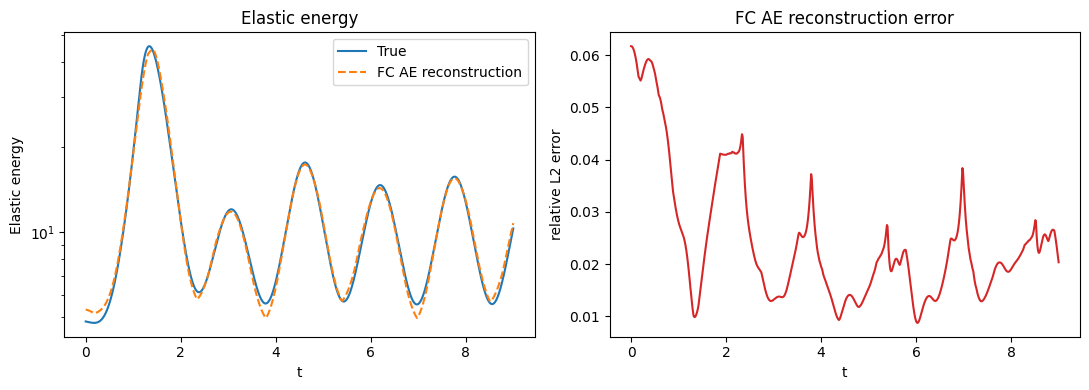

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_axis, true_energy_traj, label="True")
axes[0].plot(t_axis, rec_energy_traj, "--", label="FC AE reconstruction")
axes[0].set_yscale("log")
axes[0].set_xlabel("t"); axes[0].set_ylabel("Elastic energy")
axes[0].set_title("Elastic energy"); axes[0].legend()

axes[1].plot(t_axis, rec_error_traj, color="tab:red")
axes[1].set_xlabel("t"); axes[1].set_ylabel("relative L2 error")
axes[1].set_title("FC AE reconstruction error")
fig.tight_layout()
plt.show()

## 2. SINDy latent dynamics

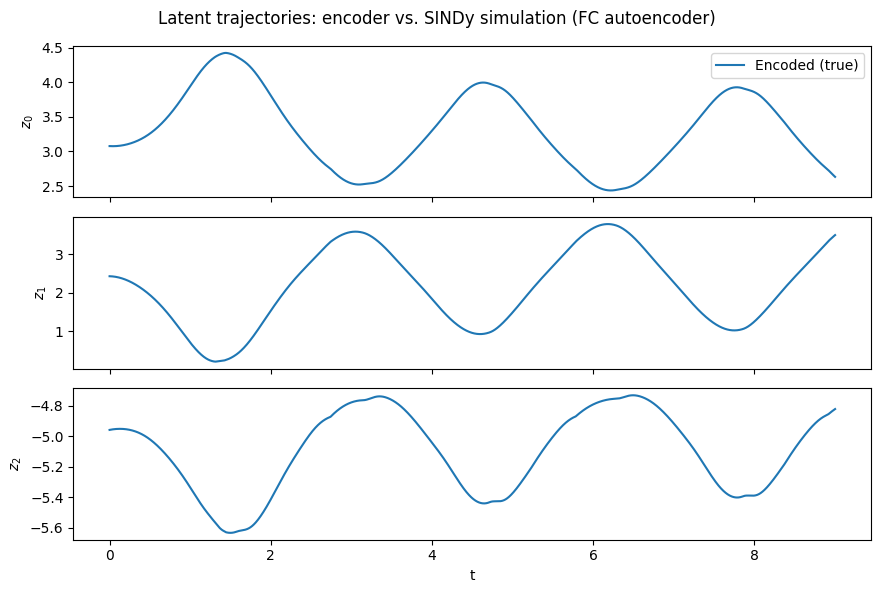

In [11]:
z0 = z_true_traj[0:1].to(device)
z_sindy_traj = rk4_integrate(model.sindy, z0, n_steps=T, dt=dt).cpu()

latent_dim = z_true_traj.shape[1]
fig, axes = plt.subplots(latent_dim, 1, figsize=(9, 2 * latent_dim), sharex=True, squeeze=False)
axes = axes[:, 0]
for i, ax in enumerate(axes):
    ax.plot(t_axis, z_true_traj[:, i].numpy(), label="Encoded (true)")
    # ax.plot(t_axis, z_sindy_traj[:, i].numpy(), "--", label="SINDy simulation")
    ax.set_ylabel(f"$z_{i}$")
axes[0].legend()
axes[-1].set_xlabel("t")
fig.suptitle("Latent trajectories: encoder vs. SINDy simulation (FC autoencoder)")
fig.tight_layout()
plt.show()

## 3. SINDy-simulated reconstruction vs. true data

In [ ]:
B_sindy_rec = chunked_decode(model, z_sindy_traj)
A_sindy_energy, sindy_trace = derive_A_products(B_sindy_rec)
sindy_energy_traj = calc_energy(A_sindy_energy, Re, Wi, beta, L2,area)


MovieWriter ffmpeg unavailable; using Pillow instead.


ffmpeg not found - saved GIF instead: fc_sindy_reconstruction.gif
Saved: fc_sindy_reconstruction.mp4


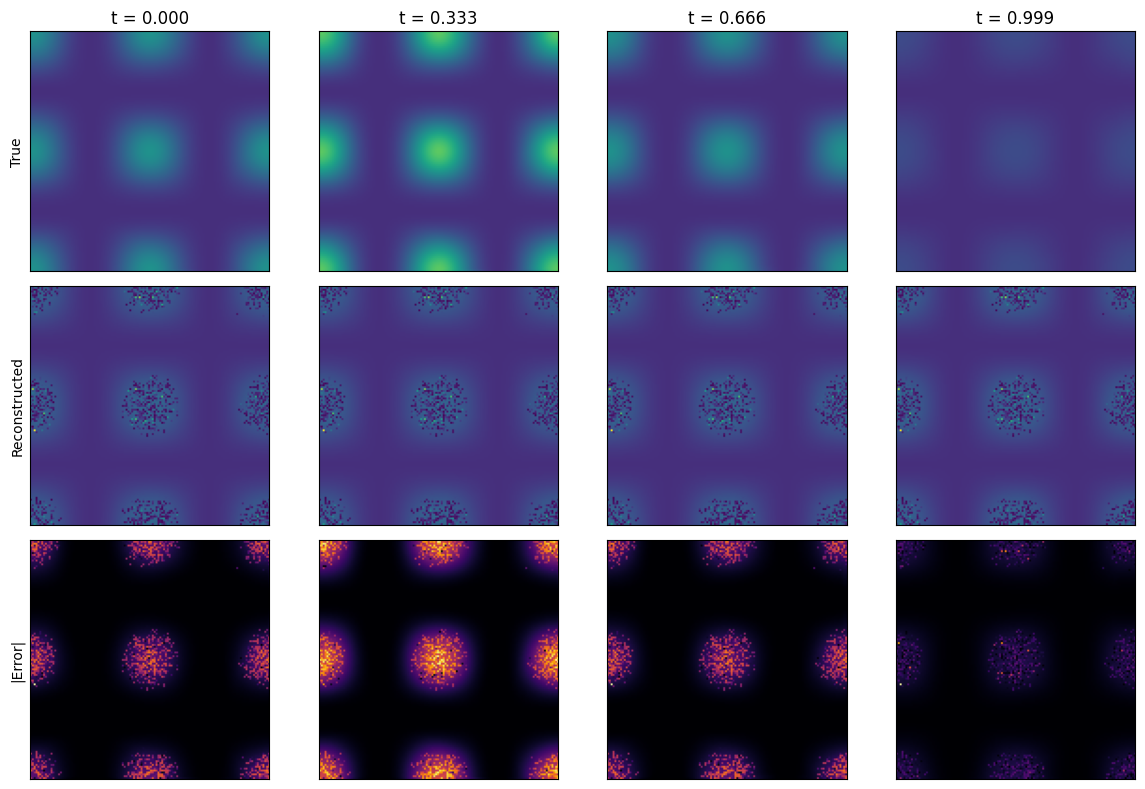

In [ ]:

fc_sindy_video_path = "fc_sindy_reconstruction.mp4"
make_comparison_video(true_trace, sindy_trace, t_axis, fc_sindy_video_path,
                       title="SINDy-simulated reconstruction (FC decoder) — tr(C)")
print(f"Saved: {fc_sindy_video_path}")
show_preview_frames(true_trace, sindy_trace, t_axis)
plt.show()

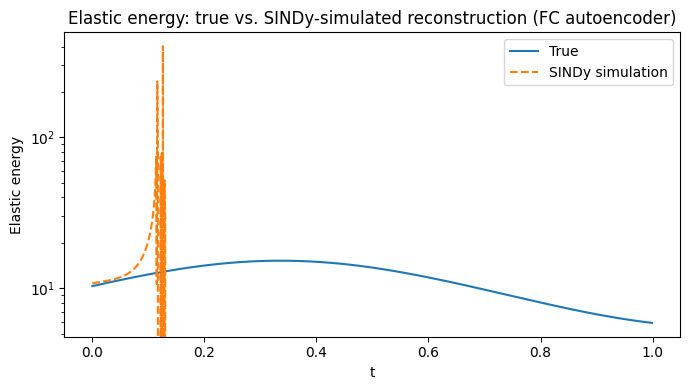

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_axis, true_energy_traj, label="True")
ax.plot(t_axis, sindy_energy_traj, "--", label="SINDy simulation")
ax.set_yscale("log")
ax.set_xlabel("t"); ax.set_ylabel("Elastic energy")
ax.set_title("Elastic energy: true vs. SINDy-simulated reconstruction (FC autoencoder)")
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
sindy = model.sindy

def _show_attr(obj, names, label):
    for name in names:
        if hasattr(obj, name):
            val = getattr(obj, name)
            if torch.is_tensor(val):
                val = val.detach().cpu().numpy()
            print(f"{label} ({name}):")
            print(val)
            return
    print(f"{label}: not found")

_show_attr(sindy, ["coef_", "coefficients", "coefs", "coef", "Xi"], "SINDy coefficients")
_show_attr(sindy, ["mask", "coef_mask", "sparsity_mask"], "SINDy mask")

SINDy coefficients (coefficients):
[[1.0987346  1.056977   1.0236104 ]
 [0.7718232  0.5917024  0.84355474]
 [0.5453822  0.6998142  0.51123565]
 [0.99419945 1.0386022  0.9047191 ]
 [0.84290415 0.71062595 0.8863386 ]
 [0.4761574  1.0222378  0.8310381 ]
 [0.87323314 0.58912283 0.7722683 ]
 [0.6118352  1.2646551  0.79120183]
 [1.7747079  0.77714354 1.2052348 ]
 [0.47490242 1.1676503  0.8833629 ]
 [0.21491398 1.2089186  0.6850264 ]
 [1.2392997  0.8314607  1.0045608 ]
 [0.4698736  0.98253554 0.6490265 ]
 [1.3642441  0.87169945 1.1119967 ]
 [1.0060214  1.0657494  1.0366894 ]
 [0.38381436 0.57791966 0.45522282]
 [1.1098201  1.1613065  1.1302732 ]
 [0.94061244 0.9120976  0.95875907]
 [0.62515146 1.0362298  0.85241777]]
SINDy mask (mask):
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


PySINDy equations:
(x0)' = 0.018 x0 + 0.055 x1 + -0.070 x2 + -0.022 x0^2 + -0.004 x0 x1 + -0.025 x0 x2 + 0.114 x1^2 + -0.135 x1 x2 + 0.200 x2^2 + -0.165 x0^3 + -0.333 x0^2 x1 + 0.225 x0^2 x2 + -0.228 x0 x1^2 + 0.308 x0 x1 x2 + -0.161 x0 x2^2 + -0.087 x1^3 + -0.025 x1^2 x2 + 0.048 x1 x2^2 + -0.335 x2^3
(x1)' = -0.015 x0 + -0.696 x1 + 0.362 x2 + 0.055 x0^2 + -0.149 x0 x1 + -0.056 x0 x2 + -2.244 x1^2 + 1.628 x1 x2 + -0.796 x2^2 + -1.676 x0^3 + 2.399 x0^2 x1 + 0.604 x0^2 x2 + -0.389 x0 x1^2 + -2.287 x0 x1 x2 + 0.531 x0 x2^2 + 2.283 x1^3 + 2.288 x1^2 x2 + -0.144 x1 x2^2
(x2)' = -0.010 x0 + 0.151 x1 + -0.045 x2 + 0.002 x0^2 + 0.046 x0 x1 + 0.036 x0 x2 + 0.538 x1^2 + -0.349 x1 x2 + 0.061 x2^2 + 0.603 x0^3 + -0.403 x0^2 x1 + -0.350 x0^2 x2 + 0.296 x0 x1^2 + 0.391 x0 x1 x2 + -0.021 x0 x2^2 + -0.574 x1^3 + -0.624 x1^2 x2 + 0.005 x1 x2^2 + 0.274 x2^3


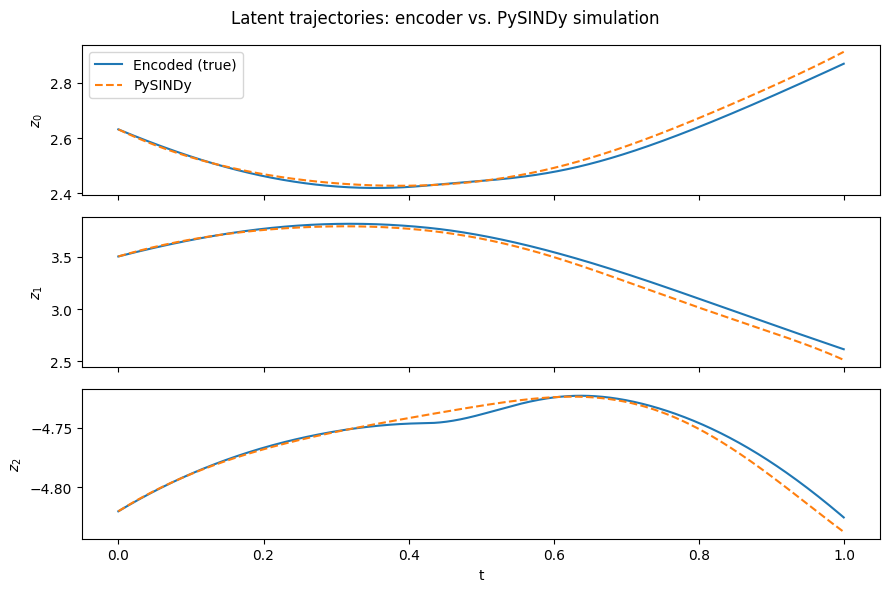

In [ ]:
import pysindy as ps

z_true_np = z_true_traj.detach().cpu().numpy()

feature_library = ps.PolynomialLibrary(
    degree=checkpoint["degree"],
    include_bias=checkpoint["include_bias"],
)
optimizer = ps.STLSQ(threshold=1e-4, alpha=1e-6)
pysindy_model = ps.SINDy(feature_library=feature_library, optimizer=optimizer)

pysindy_model.fit(z_true_np, t=dt)

print("PySINDy equations:")
pysindy_model.print()

z_pysindy_np = pysindy_model.simulate(z_true_np[0], t_axis)
z_pysindy_traj = torch.tensor(z_pysindy_np, dtype=torch.float32)

fig, axes = plt.subplots(z_true_np.shape[1], 1, figsize=(9, 2 * z_true_np.shape[1]), sharex=True, squeeze=False)
axes = axes[:, 0]
for i, ax in enumerate(axes):
    ax.plot(t_axis, z_true_np[:, i], label="Encoded (true)")
    ax.plot(t_axis, z_pysindy_np[:, i], "--", label="PySINDy")
    ax.set_ylabel(f"$z_{i}$")
axes[0].legend()
axes[-1].set_xlabel("t")
fig.suptitle("Latent trajectories: encoder vs. PySINDy simulation")
fig.tight_layout()
plt.show()

### PySINDy fit on training data, using autograd-exact dz/dt

The cell above fits PySINDy on the *test-set* encoded trajectory and lets it estimate `dz/dt` by finite-differencing `z`. Here we instead fit on the **training set**, with `dz/dt` computed exactly via the encoder Jacobian applied to the true `dB/dt` (`jvp(encoder, B, dB_dt)` — the same trick `loss_sindy_ae` uses during training), avoiding finite-difference noise entirely. The resulting model is then evaluated on the held-out test trajectory for a fair comparison.

In [ ]:
def chunked_encode_jvp(model, states, derivs, batch_size=100):
    """Encodes states and propagates derivs through the encoder Jacobian (JVP) for exact dz/dt = J_phi(x) . x_dot."""
    model.eval()
    latents, dlatents = [], []
    for i in range(0, len(states), batch_size):
        x = states[i:i + batch_size].to(device)
        x_dot = derivs[i:i + batch_size].to(device)
        x.requires_grad_(True)
        z, dzdt = jvp(model.encoder, (x,), (x_dot,))
        latents.append(z.detach().cpu())
        dlatents.append(dzdt.detach().cpu())
    return torch.cat(latents), torch.cat(dlatents)

In [ ]:
z_true_train, dzdt_true_train = chunked_encode_jvp(model, B_true_test, dB_true_test)
z_train_np = z_true_train.numpy()
dzdt_train_np = dzdt_true_train.numpy()

c:\Users\fabio\anaconda3\envs\reduction_env\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [21]:
# Second-order central difference: dA/dt ≈ (A[i+1] - A[i-1]) / (2*dt)
dz_dt_fd = np.zeros_like(z_train_np)
dz_dt_fd[1:-1, :] = (z_train_np[2:, :] - z_train_np[:-2, :]) / (2 * dt)

# For boundaries, use second-order forward/backward difference
dz_dt_fd[0, :] = (-3*z_train_np[0, :] + 4*z_train_np[1, :] - z_train_np[2, :]) / (2 * dt)
dz_dt_fd[-1, :] = (z_train_np[-3, :] - 4*z_train_np[-2, :] + 3*z_train_np[-1, :]) / (2 * dt)

PySINDy equations (fit on training data, autograd dz/dt):
(x0)' = 0.037 x0 + 0.026 x1 + -0.076 x2 + 0.020 x0^2 + 0.003 x0 x1 + -0.084 x0 x2 + 0.035 x1^2 + -0.059 x1 x2 + 0.223 x2^2 + -0.240 x0^3 + -0.271 x0^2 x1 + 0.233 x0^2 x2 + -0.016 x0 x1^2 + 0.225 x0 x1 x2 + -0.100 x0 x2^2 + -0.091 x1^3 + -0.035 x1^2 x2 + -0.070 x1 x2^2 + -0.300 x2^3
(x1)' = -0.031 x0 + -0.090 x1 + 0.120 x2 + 0.059 x0^2 + -0.015 x0 x1 + 0.030 x0 x2 + -0.129 x1^2 + 0.234 x1 x2 + -0.333 x2^2 + 0.244 x0^3 + 0.655 x0^2 x1 + -0.405 x0^2 x2 + 0.272 x0 x1^2 + -0.511 x0 x1 x2 + 0.302 x0 x2^2 + 0.234 x1^3 + 0.048 x1^2 x2 + -0.143 x1 x2^2 + 0.566 x2^3
(x2)' = -0.028 x0 + 0.040 x2 + -0.037 x0^2 + 0.001 x0 x1 + 0.074 x0 x2 + 0.002 x1^2 + -0.009 x1 x2 + -0.123 x2^2 + 0.165 x0^3 + 0.078 x0^2 x1 + -0.113 x0^2 x2 + -0.062 x0 x1^2 + -0.074 x0 x1 x2 + 0.012 x0 x2^2 + 0.022 x1^3 + 0.021 x1^2 x2 + 0.109 x1 x2^2 + 0.131 x2^3


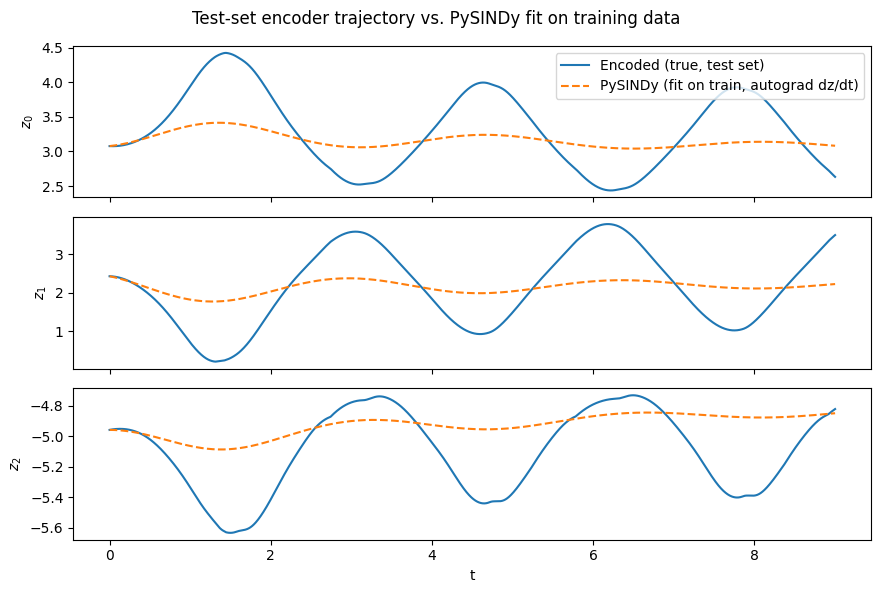

In [37]:
feature_library_train = ps.PolynomialLibrary(
    degree=checkpoint["degree"],
    include_bias=checkpoint["include_bias"],
)
optimizer_train = ps.STLSQ(threshold=1e-4, alpha=0)
pysindy_model_train = ps.SINDy(feature_library=feature_library_train, optimizer=optimizer_train)

pysindy_model_train.fit(z_train_np, t=dt)

print("PySINDy equations (fit on training data, autograd dz/dt):")
pysindy_model_train.print()

z_pysindy_train_fit_np = pysindy_model_train.simulate(z_train_np[0], t_axis)

fig, axes = plt.subplots(z_train_np.shape[1], 1, figsize=(9, 2 * z_train_np.shape[1]), sharex=True, squeeze=False)
axes = axes[:, 0]
for i, ax in enumerate(axes):
    ax.plot(t_axis, z_train_np[:, i], label="Encoded (true, test set)")
    ax.plot(t_axis, z_pysindy_train_fit_np[:, i], "--", label="PySINDy (fit on train, autograd dz/dt)")
    ax.set_ylabel(f"$z_{i}$")
axes[0].legend()
axes[-1].set_xlabel("t")
fig.suptitle("Test-set encoder trajectory vs. PySINDy fit on training data")
fig.tight_layout()
plt.show()

In [53]:
pysindy_model_train.coefficients().shape, model.sindy.mask

((3, 19),
 tensor([[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]], device='cuda:0'))

In [52]:
model.sindy.transform(z_true_traj[0:4].to(device)).shape, model.sindy.coefficients.shape

(torch.Size([4, 19]), torch.Size([19, 3]))

In [49]:
model.sindy(z_true_traj[0:4].to(device)).shape

torch.Size([4, 3])

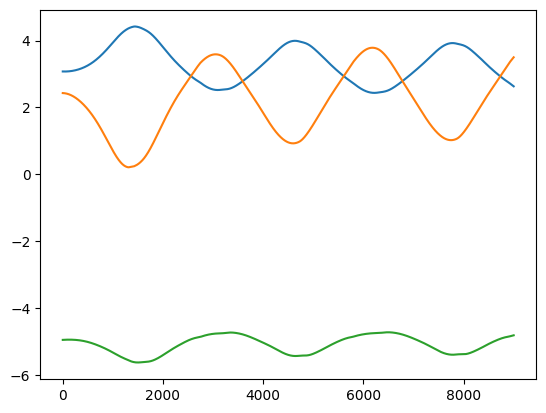

In [26]:
# plt.plot(z_train_np)
# plt.figure()
plt.plot(z_train_np)

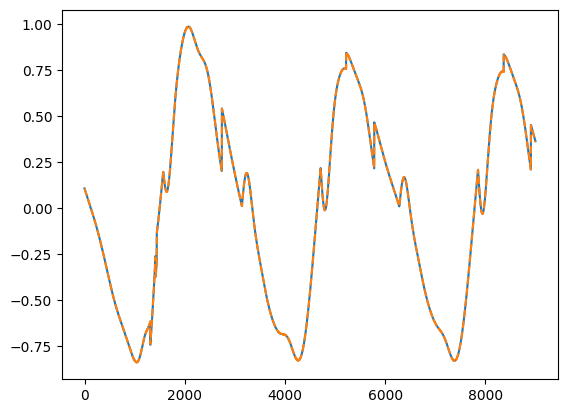

In [25]:
# plt.plot(z_train_np)
# plt.figure()
i = 2
plt.plot(dzdt_train_np[:,i])
plt.plot(dz_dt_fd[:,i], '--')


## 4. Weak-form (integral) SINDy fit

Both fits above need a `dz/dt` estimate (finite difference or the encoder-JVP) before regressing. **Weak SINDy** (`ps.WeakPDELibrary`) sidesteps that: it integrates the candidate library and the state against compactly-supported test functions and integrates by parts, so the time derivative lands on the (analytically known) test function instead of on the noisy data — no explicit `x_dot` is ever computed. This is generally more robust when `z` is noisy or the AE reconstruction is imperfect.

In [ ]:
poly_lib_weak = ps.PolynomialLibrary(
    degree=checkpoint["degree"],
    include_bias=checkpoint["include_bias"],
)
weak_lib = ps.WeakPDELibrary(
    function_library=poly_lib_weak,
    spatiotemporal_grid=t_axis,
    K=200,
)
optimizer_weak = ps.STLSQ(threshold=1e-4, alpha=1e-6)
pysindy_model_weak = ps.SINDy(feature_library=weak_lib, optimizer=optimizer_weak)

pysindy_model_weak.fit(z_train_np, t=t_axis)

print("Weak-form PySINDy equations:")
pysindy_model_weak.print()

# WeakPDELibrary.transform() is only valid over the K training subdomains it was built with,
# so it can't be evaluated pointwise inside simulate()'s ODE integration. Copy the fitted
# coefficients into a plain (non-weak) library with matching feature order for simulation.
sindy_model_weak_sim = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=checkpoint["degree"], include_bias=checkpoint["include_bias"]),
    optimizer=ps.STLSQ(threshold=1e-4, alpha=1e-6),
)
sindy_model_weak_sim.fit(z_train_np, t=t_axis)
sindy_model_weak_sim.optimizer.coef_ = pysindy_model_weak.coefficients()

z_pysindy_weak_np = sindy_model_weak_sim.simulate(z_train_np[0], t_axis)

fig, axes = plt.subplots(z_train_np.shape[1], 1, figsize=(9, 2 * z_train_np.shape[1]), sharex=True, squeeze=False)
axes = axes[:, 0]
for i, ax in enumerate(axes):
    ax.plot(t_axis, z_train_np[:, i], label="Encoded (true)")
    ax.plot(t_axis, z_pysindy_weak_np[:, i], "--", label="Weak SINDy")
    ax.set_ylabel(f"$z_{i}$")
axes[0].legend()
axes[-1].set_xlabel("t")
fig.suptitle("Latent trajectories: encoder vs. weak-form PySINDy simulation")
fig.tight_layout()
plt.show()